In [7]:
import random
import csv
from datetime import datetime, timedelta

# ==========================================
# 1. ตั้งค่าพารามิเตอร์ของ Dataset
# ==========================================
TOTAL_SESSIONS = 1500 # ใช้การจำลองเป็น Session (1 Session อาจมีหลายบรรทัด Log)
NORMAL_RATIO = 0.70

# สร้าง IP และรหัสผ่านที่หลากหลายกว่าเดิม
normal_ips = [f"192.168.1.{i}" for i in range(10, 110)] + [f"10.0.0.{i}" for i in range(100, 200)] # 200 IPs
bot_ips = [f"{random.randint(11,250)}.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(1,254)}" for _ in range(400)]

base_pwds = ["admin", "123456", "root", "password", "qwerty", "111111", "admin123", "system"]
passwords = list(set(base_pwds + [f"pass{random.randint(1000, 99999)}" for _ in range(300)]))

normal_users = ["pitchayut", "admin", "dev_ops", "system_admin", "db_admin", "user1", "test"]
bot_users = ["root", "admin", "oracle", "test", "ubuntu", "guest", "pi", "mysql", "ftpuser", "postgres"]

records = []
base_time = datetime(2024, 7, 31, 0, 0, 0)

# ==========================================
# 2. ฟังก์ชันจำลองพฤติกรรมมนุษย์ (Normal - 70%)
# ==========================================
def generate_human_session():
    logs = []
    ip = random.choice(normal_ips)
    user = random.choice(normal_users)
    port = random.randint(40000, 65000)
    # สุ่มเวลาให้กระจายตลอด 24 ชั่วโมง
    current_time = base_time + timedelta(seconds=random.randint(0, 86400))
    
    scenario = random.random()
    if scenario < 0.60:
        # เคส 1: ล็อกอินครั้งเดียวผ่าน (ปกติที่สุด)
        logs.append((current_time, "Accepted password", user, ip, port, "***HIDDEN***", 0))
    
    elif scenario < 0.85:
        # เคส 2: พิมพ์ผิด 1-2 ครั้งแบบหน่วงเวลา (มนุษย์ทั่วไป)
        attempts = random.randint(1, 2)
        for _ in range(attempts):
            logs.append((current_time, "Failed password", user, ip, port, "typo_pass", 0))
            current_time += timedelta(seconds=random.randint(8, 20)) # หน่วงเวลาคิด
        logs.append((current_time, "Accepted password", user, ip, port, "***HIDDEN***", 0))
        
    else:
        # เคส 3 (OUTLIER): มนุษย์หัวร้อน รีบพิมพ์ผิดรัวๆ (ดูคล้ายบอท)
        attempts = random.randint(3, 5)
        for _ in range(attempts):
            logs.append((current_time, "Failed password", user, ip, port, "fast_typo", 0))
            current_time += timedelta(seconds=random.uniform(0.5, 2.0)) # พิมพ์รัวมากระดับเสี้ยววินาที
        logs.append((current_time, "Accepted password", user, ip, port, "***HIDDEN***", 0))
        
    return logs

# ==========================================
# 3. ฟังก์ชันจำลองพฤติกรรมบอท (Anomaly - 30%)
# ==========================================
def generate_bot_session():
    logs = []
    ip = random.choice(bot_ips)
    port = random.randint(10000, 65000)
    current_time = base_time + timedelta(seconds=random.randint(0, 86400))
    
    scenario = random.random()
    if scenario < 0.80:
        # เคส 1: Fast Brute-force (บอทยิงรัวๆ มาตรฐาน)
        attempts = random.randint(15, 40)
        for _ in range(attempts):
            logs.append((current_time, "Failed password", random.choice(bot_users), ip, port, random.choice(passwords), 1))
            current_time += timedelta(seconds=random.uniform(0.1, 1.5)) # ถี่มาก
    else:
        # เคส 2 (OUTLIER): Low & Slow Attack (บอทเนียนเป็นคน หน่วงเวลาหลบ Firewall)
        attempts = random.randint(5, 15)
        for _ in range(attempts):
            logs.append((current_time, "Failed password", random.choice(bot_users), ip, port, random.choice(passwords), 1))
            current_time += timedelta(seconds=random.randint(25, 60)) # หน่วงเวลานานผิดปกติของบอท
            
    return logs

# ==========================================
# 4. สร้างข้อมูลและผสมกัน
# ==========================================
for i in range(TOTAL_SESSIONS):
    if i < TOTAL_SESSIONS * NORMAL_RATIO:
        records.extend(generate_human_session())
    else:
        records.extend(generate_bot_session())

# จัดเรียงตาม Timestamp เพื่อให้เหตุการณ์มนุษย์กับบอทสลับกันไปมาแบบสมจริง
records.sort(key=lambda x: x[0])

# ==========================================
# 5. เขียนลงไฟล์ 2 ไฟล์
# ==========================================
features_file = "ssh_dataset_features.csv"
gt_file = "ssh_ground_truth.csv"

with open(features_file, "w", newline="", encoding="utf-8") as f_feat, \
     open(gt_file, "w", newline="", encoding="utf-8") as f_gt:
    
    feat_writer = csv.writer(f_feat)
    gt_writer = csv.writer(f_gt)
    
    # เขียน Header
    feat_writer.writerow(["Log_ID", "Timestamp", "Event", "Username", "Source_IP", "Source_Port", "Password"])
    gt_writer.writerow(["Log_ID", "Label"])
    
    normal_count = 0
    anomaly_count = 0
    
    for idx, row in enumerate(records):
        log_id = f"LOG_{idx+1:06d}"
        timestamp_str = row[0].strftime("%Y-%m-%d %H:%M:%S.%f")[:-3] # มีระดับมิลลิวินาทีให้สมจริงขึ้น
        event, user, ip, port, pwd, label = row[1], row[2], row[3], row[4], row[5], row[6]
        
        feat_writer.writerow([log_id, timestamp_str, event, user, ip, port, pwd])
        gt_writer.writerow([log_id, label])
        
        if label == 0: normal_count += 1
        else: anomaly_count += 1

print(f"✅ สร้างไฟล์ Dataset ที่มีความสมจริงและมี Outlier เรียบร้อยแล้ว!")
print(f"   - Normal Traffic: {normal_count} แถว")
print(f"   - Anomaly Traffic: {anomaly_count} แถว")

✅ สร้างไฟล์ Dataset ที่มีความสมจริงและมี Outlier เรียบร้อยแล้ว!
   - Normal Traffic: 2130 แถว
   - Anomaly Traffic: 10811 แถว


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import joblib

# 1. โหลดข้อมูลจากไฟล์ CSV ที่สร้างไว้
df_features = pd.read_csv("ssh_dataset_features.csv")
df_gt = pd.read_csv("ssh_ground_truth.csv")

# 2. รวมตาราง (Merge) ด้วย Log_ID เพื่อนำ Label มาจับคู่กับ Features
df = pd.merge(df_features, df_gt, on="Log_ID")

# 3. แปลงคอลัมน์ Timestamp ให้เป็นชนิดข้อมูล Datetime ของ Pandas
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print(f"ขนาดของ Dataset ทั้งหมด: {df.shape}")
display(df.head())

ขนาดของ Dataset ทั้งหมด: (12941, 8)


,Log_ID,Timestamp,Event,Username,Source_IP,Source_Port,Password,Label
0,LOG_000001,2024-07-31 00:01:47.000,Failed password,test,192.168.1.80,62464,fast_typo,0
1,LOG_000002,2024-07-31 00:01:47.598,Failed password,test,192.168.1.80,62464,fast_typo,0
2,LOG_000003,2024-07-31 00:01:48.855,Failed password,test,192.168.1.80,62464,fast_typo,0
3,LOG_000004,2024-07-31 00:01:49.000,Accepted password,test,10.0.0.166,59329,***HIDDEN***,0
4,LOG_000005,2024-07-31 00:01:50.417,Failed password,test,192.168.1.80,62464,fast_typo,0


In [3]:
# ---------------------------------------------------------
# 1. ฟีเจอร์พื้นฐานจากข้อความ (Text-based Features)
# ---------------------------------------------------------
df['Username_Length'] = df['Username'].astype(str).apply(len)

target_users = ['root', 'admin', 'ubuntu', 'oracle', 'test', 'pi', 'ftpuser', 'postgres', 'system']
df['Is_Target_User'] = df['Username'].isin(target_users).astype(int)

# สร้างตัวแปรชั่วคราวเพื่อเช็คสถานะการล็อกอิน
df['Is_Failed'] = (df['Event'] == 'Failed password').astype(int)

# ---------------------------------------------------------
# 2. ฟีเจอร์เชิงพฤติกรรมเวลา (Time-Window Features)
# ---------------------------------------------------------
# เรียงข้อมูลตาม IP และเวลา เพื่อคำนวณแยกราย IP
df = df.sort_values(['Source_IP', 'Timestamp'])

# ระยะเวลาห่างจากการพยายามครั้งล่าสุด (วินาที)
df['Time_Since_Last'] = df.groupby('Source_IP')['Timestamp'].diff().dt.total_seconds().fillna(0)

# จำนวนครั้งที่พลาดติดต่อกัน (รีเซ็ตเมื่อล็อกอินสำเร็จ)
df['Fail_Block'] = (df['Is_Failed'] == 0).groupby(df['Source_IP']).cumsum()
df['Consecutive_Fails'] = df.groupby(['Source_IP', 'Fail_Block'])['Is_Failed'].cumsum()

# ---------------------------------------------------------
# 3. ฟีเจอร์แบบ Rolling Window (กรอบเวลา 15 วินาที)
# ---------------------------------------------------------
df = df.sort_values('Timestamp').set_index('Timestamp')

# จำนวนที่พลาดใน 15 วินาทีย้อนหลัง
df['Failed_Count_15s'] = df.groupby('Source_IP')['Is_Failed'].transform(
    lambda x: x.rolling('15s').sum()
)

# ความหลากหลายของ Username ใน 15 วินาที
df['Temp_User_ID'] = df.groupby('Username').ngroup()
df['Unique_Users_15s'] = df.groupby('Source_IP')['Temp_User_ID'].transform(
    lambda x: x.rolling('15s').apply(lambda y: len(np.unique(y)), raw=True)
).fillna(1)

# คืนค่า Index และลบคอลัมน์ตัวช่วยทิ้ง
df = df.reset_index()
df = df.drop(columns=['Fail_Block', 'Temp_User_ID', 'Is_Failed'])

features_list = [
    'Username_Length', 
    'Is_Target_User', 
    'Time_Since_Last', 
    'Consecutive_Fails', 
    'Failed_Count_15s', 
    'Unique_Users_15s'
]

print("✅ สกัด 6 Features เสร็จสมบูรณ์")
display(df[['Source_IP', 'Event'] + features_list + ['Label']].tail(10))

✅ สกัด 6 Features เสร็จสมบูรณ์


,Source_IP,Event,Username_Length,Is_Target_User,Time_Since_Last,Consecutive_Fails,Failed_Count_15s,Unique_Users_15s,Label
12931,149.204.233.226,Failed password,4,1,36.0,32,1.0,1.0,1
12932,78.199.106.54,Failed password,2,1,43.0,27,1.0,1.0,1
12933,149.204.233.226,Failed password,2,1,30.0,33,1.0,1.0,1
12934,149.204.233.226,Failed password,5,0,34.0,34,1.0,1.0,1
12935,149.204.233.226,Failed password,7,1,60.0,35,1.0,1.0,1
12936,149.204.233.226,Failed password,6,1,39.0,36,1.0,1.0,1
12937,149.204.233.226,Failed password,8,1,32.0,37,1.0,1.0,1
12938,149.204.233.226,Failed password,2,1,37.0,38,1.0,1.0,1
12939,149.204.233.226,Failed password,8,1,37.0,39,1.0,1.0,1
12940,149.204.233.226,Failed password,8,1,46.0,40,1.0,1.0,1


In [20]:
%pip install --upgrade matplotlib seaborn

^C
Note: you may need to restart the kernel to use updated packages.


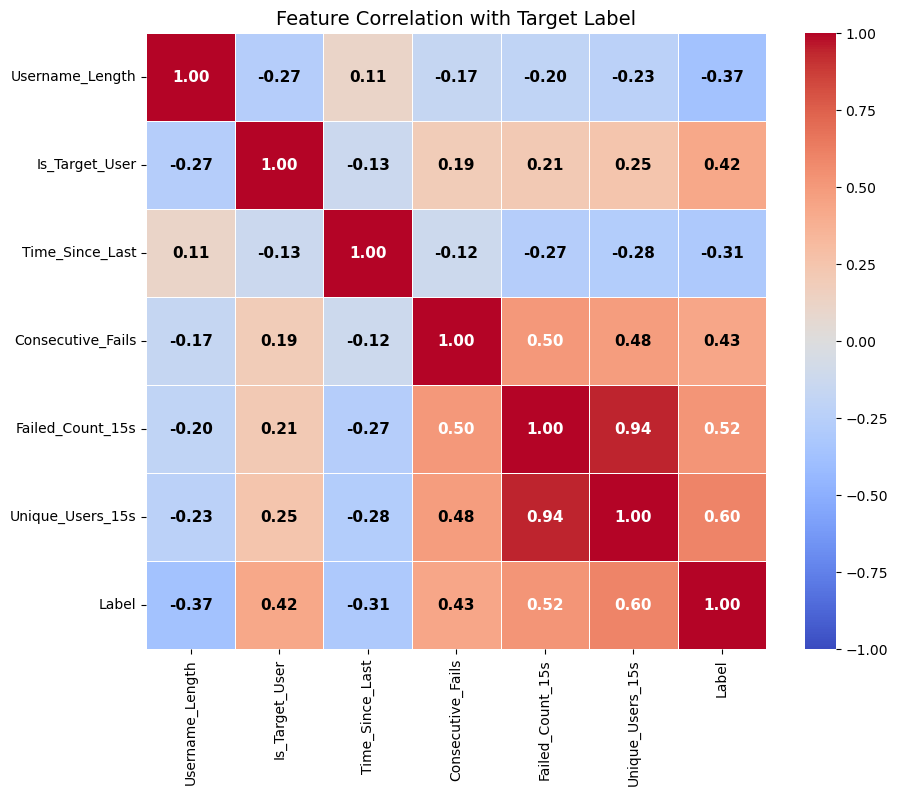

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# คำนวณ Correlation
corr_matrix = df[features_list + ['Label']].corr()

plt.figure(figsize=(10, 8))

# ปิด annot=False เพื่อเลี่ยงบั๊กของไลบรารี
ax = sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

# วนลูปวาดตัวเลขลงไปตรงกลางทุกกล่องด้วยตัวเอง
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.iloc[i, j]
        # สลับสีตัวอักษรให้ตัดกับพื้นหลัง (สีเข้มใช้ตัวหนังสือขาว สีอ่อนใช้ตัวหนังสือดำ)
        text_color = "white" if abs(val) > 0.5 else "black"
        
        ax.text(j + 0.5, i + 0.5, f"{val:.2f}", 
                ha="center", va="center", color=text_color, fontsize=11, weight='bold')

plt.title("Feature Correlation with Target Label", fontsize=14)
plt.show()

In [10]:
# กำหนดตัวแปรต้น (X) และตัวแปรตาม (y)
X = df[features_list]
y = df['Label']

# แบ่งข้อมูลสำหรับ Train 80% และ Test 20% (Stratify เพื่อให้สัดส่วน Normal/Anomaly สมดุล)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"จำนวนข้อมูล Train: {X_train.shape[0]} แถว")
print(f"จำนวนข้อมูล Test: {X_test.shape[0]} แถว\n")

# สร้างและฝึกสอนโมเดล Random Forest
# ตั้งค่า max_depth=5 เพื่อป้องกันการ Overfit
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

print("🌲 เทรนโมเดล Random Forest สำเร็จ!")

จำนวนข้อมูล Train: 10352 แถว
จำนวนข้อมูล Test: 2589 แถว

🌲 เทรนโมเดล Random Forest สำเร็จ!


🔥 Model Accuracy: 99.58%

📊 Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.99      0.99      0.99       426
 Anomaly (1)       1.00      1.00      1.00      2163

    accuracy                           1.00      2589
   macro avg       0.99      0.99      0.99      2589
weighted avg       1.00      1.00      1.00      2589



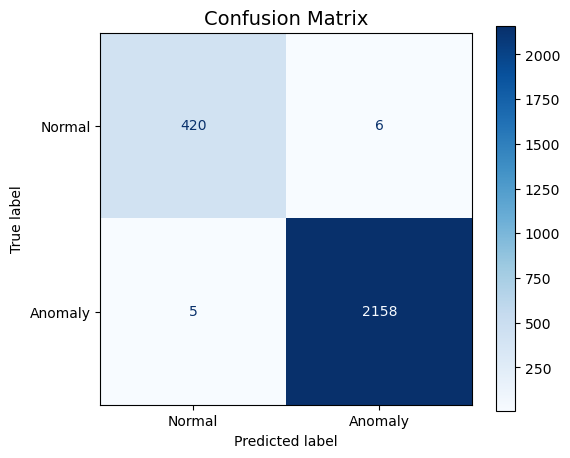


📈 ระดับความสำคัญของฟีเจอร์ (Feature Importance):


,Feature,Importance
3,Consecutive_Fails,0.395591
5,Unique_Users_15s,0.247804
4,Failed_Count_15s,0.123812
2,Time_Since_Last,0.092246
0,Username_Length,0.083198
1,Is_Target_User,0.057350


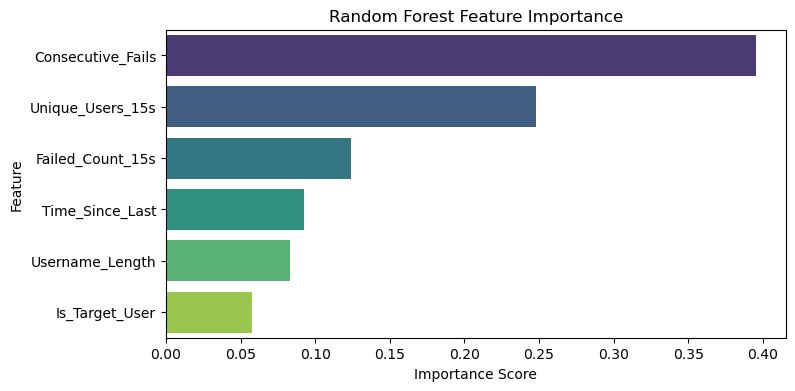

In [11]:
# ให้โมเดลทำนายข้อมูลชุด Test
y_pred = model.predict(X_test)

# 1. ความแม่นยำรวม (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"🔥 Model Accuracy: {accuracy * 100:.2f}%\n")

# 2. รายงาน Precision, Recall, F1-Score
print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal (0)", "Anomaly (1)"]))

# 3. สร้างกราฟ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix", fontsize=14)
plt.show()

# 4. ดูความสำคัญของฟีเจอร์ (Feature Importance)
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': features_list, 
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n📈 ระดับความสำคัญของฟีเจอร์ (Feature Importance):")
display(feature_imp_df)

# วาดกราฟ Feature Importance
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [12]:
# บันทึกโมเดลและรายชื่อฟีเจอร์ลงไฟล์ .pkl
model_bundle = {
    "model": model,
    "feature_names": features_list
}

joblib.dump(model_bundle, "bruteforce_rf_model.pkl")
print("💾 บันทึกไฟล์ 'bruteforce_rf_model.pkl' เสร็จสมบูรณ์ พร้อมนำไปเชื่อมต่อกับ Streamlit")

💾 บันทึกไฟล์ 'bruteforce_rf_model.pkl' เสร็จสมบูรณ์ พร้อมนำไปเชื่อมต่อกับ Streamlit
